# 🔬 AO3 Fanfic Dataset Pipeline

Pipeline para construir un dataset de fanfics + comentarios desde AO3.

**Estructura:** 4 fandoms × 4 tropes × 15 fics = 240 fics

| Paso | Módulo | Descripción |
|------|--------|-------------|
| 1 | config.py | Parámetros centrales |
| 2 | scraper.py | Scraping de AO3 (fics + comentarios) |
| 3 | supplementer.py | Rellena celdas incompletas con datasets públicos |
| 4 | builder.py | Genera CSV, JSONL y reporte final |

## 2. Configuración

Revisa y ajusta los parámetros antes de correr. Los valores por defecto están listos para usar.

In [1]:
with open(".env", "w") as f:
    f.write("AO3_USERNAME=stray_gemini\n")
    f.write("AO3_PASSWORD=Uzumaki2003#\n")

print("Done — .env created")

import os
print(os.listdir("."))

with open(".env") as f:
    print(f.read())

Done — .env created
['config.py', 'scraper1.py', 'supplementer.py', 'ao3_auth.py', 'builder.py', '.env', 'old_scraper.py', 'ao3_pipeline.ipynb', '.ipynb_checkpoints', '__pycache__']
AO3_USERNAME=stray_gemini
AO3_PASSWORD=Uzumaki2003#



In [2]:
print(os.getcwd())

/home/mariana/proyecto_PAT


In [1]:
import requests
from bs4 import BeautifulSoup
import time

# Build the session manually here first
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "FanficResearchScraper/1.0 (academic NLP project)"})
SESSION.cookies.update({"accepted_tos": "20180523", "view_adult": "true"})

# Login
time.sleep(3)
resp = SESSION.get("https://archiveofourown.org/users/login", timeout=20)
soup = BeautifulSoup(resp.text, "html.parser")
token = soup.find("input", {"name": "authenticity_token"})["value"]

time.sleep(3)
post = SESSION.post(
    "https://archiveofourown.org/users/login",
    data={
        "utf8": "✓",
        "authenticity_token": token,
        "user[login]": "stray_gemini",      # ← paste yours
        "user[password]": "Uzumaki2003#",   # ← paste yours
        "user[remember_me]": "0",
        "commit": "Log In",
    },
    headers={"Referer": "https://archiveofourown.org/users/login"},
    timeout=20,
    allow_redirects=True,
)

if "logout" in post.text.lower():
    print("✓ Logged in successfully")
else:
    print("✗ Login failed — check credentials")


✓ Logged in successfully


In [2]:
import requests, time, urllib.parse
from bs4 import BeautifulSoup

time.sleep(3)
resp = SESSION.get("https://archiveofourown.org/users/login", timeout=60)
soup = BeautifulSoup(resp.text, "html.parser")
token = soup.find("input", {"name": "authenticity_token"})["value"]

time.sleep(3)
post = SESSION.post(
    "https://archiveofourown.org/users/login",
    data=urllib.parse.urlencode({
        "utf8": "✓",
        "authenticity_token": token,
        "user[login]": "stray_gemini",
        "user[password]": "Uzumaki2003#",
        "user[remember_me]": "0",
        "commit": "Log In",
    }).encode("utf-8"),
    headers={
        "Referer": "https://archiveofourown.org/users/login",
        "Content-Type": "application/x-www-form-urlencoded; charset=UTF-8",
    },
    timeout=30,
    allow_redirects=True,
)
print(f"Final URL: {post.url}")
print(f"Logged in: {'logout' in post.text.lower()}")

Final URL: https://archiveofourown.org/users/stray_gemini
Logged in: True


In [3]:
import scraper1, importlib
importlib.reload(scraper1)
scraper1.SESSION.cookies.update(SESSION.cookies)
print("✓ Session patched")

✓ Session patched


In [ ]:
# from ao3_auth import login, load_credentials
# from scraper1 import SESSION

# # Log in once — the SESSION cookie persists for all subsequent requests
# username, password = load_credentials()
# success = login(SESSION, username, password)

# if success:
#     print("✓ Logged in — ready to scrape")
# else:
#     print("✗ Login failed — check your .env file")

In [4]:
# Load the settings to verify
from config import (
    FANDOMS, TROPES,
    MIN_KUDOS, MIN_COMMENT_WORDS,
    FICS_PER_CELL, TOP_N_COMMENTS,
    REQUEST_DELAY_SEC, MAX_RETRIES,
    OUTPUT_DIR, CHECKPOINT,
)

# v2 selection constants (defined in scraper1.py, not config)
from scraper1 import MIN_CHAPTERS, MAX_CHAPTERS, MIN_AVG_WORDS, MAX_AVG_WORDS, MIN_COMMENTS_PER_CHAPTER

print("=" * 50)
print("CONFIGURACIÓN ACTUAL")
print("=" * 50)

print(f"\nFandoms ({len(FANDOMS)}):")
for k, v in FANDOMS.items():
    print(f"  {k}: {v}")

print(f"\nTropes ({len(TROPES)}):")
for k, v in TROPES.items():
    print(f"  {k}: {v['ao3_tag']} → arco esperado: {v['expected_arc']}")

total = len(FANDOMS) * len(TROPES) * FICS_PER_CELL
print(f"\nTarget: {len(FANDOMS)} × {len(TROPES)} × {FICS_PER_CELL} = {total} fics")
print(f"\nFiltros de selección:")
print(f"  kudos ≥ {MIN_KUDOS}")
print(f"  capítulos: {MIN_CHAPTERS}–{MAX_CHAPTERS}")
print(f"  palabras/capítulo: {MIN_AVG_WORDS:,}–{MAX_AVG_WORDS:,}")
print(f"  comentarios/capítulo ≥ {MIN_COMMENTS_PER_CHAPTER}")
print(f"  comment words ≥ {MIN_COMMENT_WORDS}")
print(f"\nDelay entre requests: {REQUEST_DELAY_SEC}s + jitter")
print(f"Output: {OUTPUT_DIR}")

CONFIGURACIÓN ACTUAL

Fandoms (4):
  harry_potter: Harry Potter - J. K. Rowling
  bts: 방탄소년단 | Bangtan Boys | BTS
  one_direction: One Direction (Band)
  twilight: Twilight Series - Stephenie Meyer

Tropes (4):
  hurt_comfort: Hurt/Comfort → arco esperado: U-shape
  fluff: Fluff → arco esperado: flat-positive
  whump: Whump → arco esperado: sustained-low
  slow_burn: Slow Burn → arco esperado: rising

Target: 4 × 4 × 30 = 480 fics

Filtros de selección:
  kudos ≥ 500
  capítulos: 1–25
  palabras/capítulo: 1,500–40,000
  comentarios/capítulo ≥ 3
  comment words ≥ 15

Delay entre requests: 5s + jitter
Output: /home/mariana/proyecto_PAT/data/raw


## 3. Test de conexión a AO3

Antes de lanzar el scraping completo, verificamos que AO3 responde y no estamos bloqueados.

In [ ]:
# import requests
# import time

# print("Probando conexión a AO3...")
# try:
#     resp = requests.get(
#         "https://archiveofourown.org",
#         headers={"User-Agent": "FanficResearchScraper/1.0"},
#         timeout=15
#     )
#     print(f"  Status: {resp.status_code}")
#     if resp.status_code == 200:
#         print("  ✅ Conexión exitosa")
#     elif resp.status_code == 429:
#         print("  ⚠️  Rate limited — espera unos minutos antes de continuar")
#     else:
#         print(f"  ❌ Respuesta inesperada: {resp.status_code}")
# except Exception as e:
#     print(f"  ❌ Error de conexión: {e}")

## 4. Scraping de prueba (una celda)

Probamos con **una sola combinación** fandom×trope para verificar que todo funciona antes de lanzar el scraping completo. Esto trae solo 2 fics.

In [15]:
# import importlib
# import scraper1
# importlib.reload(scraper1)
from scraper1 import search_works, fetch_work, SESSION
import json, os

# Escoge la celda de prueba
test_fandom_key = "harry_potter"
test_trope_key  = "fluff"

test_fandom_tag = FANDOMS[test_fandom_key]
test_trope_tag  = TROPES[test_trope_key]["ao3_tag"]

print(f"Buscando: {test_fandom_tag} + {test_trope_tag}")
print("Esto puede tardar ~30 segundos por el rate limiting")

# Buscar solo 2 stubs para la prueba
stubs = search_works(test_fandom_tag, test_trope_tag, n=2)
print(f"Encontrados {len(stubs)} stubs:")
for s in stubs[:5]:
    print(f"  [{s['work_id']}] {s['title']} (kudos={s['kudos']}, words={s['words']})")

# Intentar traer el primero completo
if stubs:
    print(f"Descargando fic de prueba: {stubs[2]['title']}...")
    test_record = fetch_work(stubs[2], test_fandom_key, test_trope_key)
    if test_record:
        total_comments = sum(len(ch['comments']) for ch in test_record['chapters'])
        print(f"  ✅ Capítulos: {len(test_record['chapters'])}")
        print(f"  ✅ Comentarios totales: {total_comments}")
        print(f"  ✅ Tags: {test_record['tags'][:5]}")
        ch1 = test_record['chapters'][0]
        print(f"  ✅ Capítulo 1 preview: {ch1['text'][:300]}")
        print(f"  ✅ Capítulo 1 comentarios: {len(ch1['comments'])}")
        if ch1['comments']:
            print(f"  ✅ Primer comentario: {ch1['comments'][0]['text'][:150]}")
    else:
        print("  ❌ No pasó los filtros de calidad")
else:
    print("  ❌ No se encontraron resultados")

Buscando: Harry Potter - J. K. Rowling + Fluff
Esto puede tardar ~30 segundos por el rate limiting
  Searching: Harry Potter - J. K. Rowling + Fluff
  URL: https://archiveofourown.org/tags/Harry%20Potter%20-%20J*d*%20K*d*%20Rowling/works?work_search%5Bother_tag_names%5D=Fluff&work_search%5Bcomplete%5D=T&work_search%5Bsort_column%5D=kudos_count&work_search%5Bsort_direction%5D=desc&page=1
Encontrados 8 stubs:
  [10057010] All the Young Dudes (kudos=308048, words=526969)
  [39760044] Crimson Rivers (kudos=73741, words=865000)
  [3101099] The Standard You Walk Past (kudos=71031, words=46202)
  [4371455] hello goodbye ('twas nice to know you) (kudos=59364, words=4807)
  [2734082] Tea and No Sympathy (kudos=57133, words=70045)
Descargando fic de prueba: The Standard You Walk Past...
    Fetching work 3101099: The Standard You Walk Past
      Page title: The Standard You Walk Past - Chapter 1 - bafflinghaze - Harr
      Chapters: 14
      Avg words/chapter: 3300
      Chapter 6718733: fetchin

## 5. Scraping completo

⚠️ **Esto tarda varias horas** (5-7s por request × ~500+ requests).

El checkpoint guarda progreso después de cada fic, así que puedes interrumpir y retomar.
Si el kernel se reinicia, simplemente vuelve a correr esta celda.

In [1]:
# import importlib
# import scraper1
# importlib.reload(scraper1)
from scraper1 import scrape_all

scrape_all()

  [harry_potter/hurt_comfort] complete — skipping
  [harry_potter/fluff] complete — skipping
  [harry_potter/whump] complete — skipping
  [harry_potter/slow_burn] complete — skipping

[bts × hurt_comfort]
  Searching: 방탄소년단 | Bangtan Boys | BTS + Hurt/Comfort
  URL: https://archiveofourown.org/tags/%EB%B0%A9%ED%83%84%EC%86%8C%EB%85%84%EB%8B%A8%20%7C%20Bangtan%20Boys%20%7C%20BTS/works?work_search%5Bother_tag_names%5D=Hurt%2FComfort&work_search%5Bcomplete%5D=T&work_search%5Bsort_column%5D=kudos_count&work_search%5Bsort_direction%5D=desc&page=1
  URL: https://archiveofourown.org/tags/%EB%B0%A9%ED%83%84%EC%86%8C%EB%85%84%EB%8B%A8%20%7C%20Bangtan%20Boys%20%7C%20BTS/works?work_search%5Bother_tag_names%5D=Hurt%2FComfort&work_search%5Bcomplete%5D=T&work_search%5Bsort_column%5D=kudos_count&work_search%5Bsort_direction%5D=desc&page=2
  URL: https://archiveofourown.org/tags/%EB%B0%A9%ED%83%84%EC%86%8C%EB%85%84%EB%8B%A8%20%7C%20Bangtan%20Boys%20%7C%20BTS/works?work_search%5Bother_tag_names%5D=Hurt

  bts/hurt_comfort:   0%|                               | 0/120 [00:00<?, ?it/s]

    Fetching work 16962474: Somebody To Love


  bts/hurt_comfort:   2%|▌                      | 3/120 [00:06<04:24,  2.26s/it]

      Page title: Somebody To Love - Chapter 1 - LOVERVMINS (orphan_account) -
      Chapters: 29
      ✗ Chapter count 29 outside 1–25
    Fetching work 13539774: lover not a fighter, but i'll fight for what i lov


...

        Comments page 1: 2 qualifying
      Avg comments/chapter: 1.4
      ✗ Not enough chapter-level comments
    Fetching work 65551207: Always Kind of Was
      Page title: Always Kind of Was - Chapter 1 - gossameres - Multifandom [A
      Chapters: 13
      Avg words/chapter: 2090
      Chapter 168749428: fetching text...
        1531 words — fetching comments...
        Comments page 1: 1 qualifying
      Chapter 168811978: fetching text...
        1953 words — fetching comments...
        Comments page 1: 0 qualifying
      Chapter 168831760: fetching text...
        1653 words — fetching comments...
        Comments page 1: 1 qualifying
      Chapter 168908089: fetching text...
        1872 words — fetching comments...
        Comments page 1: 0 qualifying
      Chapter 168911959: fetching text...
        1665 words — fetching comments...
        Comments page 1: 1 qualifying
      Chapter 169018792: fetching text...
        1587 words — fetching comments...
      Chapter 16905

  twilight/slow_burn:  98%|█████████████████▋| 48/49 [1:16:29<02:24, 144.94s/it]

        Comments page 1: 8 qualifying
      Avg comments/chapter: 1.0
      ✗ Not enough chapter-level comments
    Fetching work 14589636: Tenebrity


  twilight/slow_burn: 100%|███████████████████| 49/49 [1:16:35<00:00, 93.78s/it]

      Page title: Tenebrity - Chapter 1 - inelegancy - Multifandom [Archive of
      Chapters: 37
      ✗ Chapter count 37 outside 1–25

Scraping complete.


In [2]:
import os
from config import FANDOMS, TROPES, OUTPUT_DIR, FICS_PER_CELL

print(f"{"Celda":<35} {"Fics":>5} / {FICS_PER_CELL}  Status")
print("-" * 60)

total = 0
complete_cells = 0

for fandom_key in FANDOMS:
    for trope_key in TROPES:
        cell_dir = os.path.join(OUTPUT_DIR, fandom_key, trope_key)
        if os.path.isdir(cell_dir):
            n = len([f for f in os.listdir(cell_dir) if f.endswith(".json")])
        else:
            n = 0
        total += n
        status = "✅" if n >= FICS_PER_CELL else ("🔄" if n > 0 else "⬜")
        if n >= FICS_PER_CELL:
            complete_cells += 1
        label = f"{fandom_key}/{trope_key}"
        print(f"{label:<35} {n:>5} / {FICS_PER_CELL}  {status}")

target = len(FANDOMS) * len(TROPES) * FICS_PER_CELL
print(f"\nTotal: {total}/{target} fics  |  Celdas completas: {complete_cells}/{len(FANDOMS)*len(TROPES)}")

Celda                                Fics / 30  Status
------------------------------------------------------------
harry_potter/hurt_comfort              30 / 30  ✅
harry_potter/fluff                     30 / 30  ✅
harry_potter/whump                     30 / 30  ✅
harry_potter/slow_burn                 30 / 30  ✅
bts/hurt_comfort                       30 / 30  ✅
bts/fluff                              30 / 30  ✅
bts/whump                              24 / 30  🔄
bts/slow_burn                          30 / 30  ✅
one_direction/hurt_comfort             30 / 30  ✅
one_direction/fluff                    30 / 30  ✅
one_direction/whump                     0 / 30  ⬜
one_direction/slow_burn                30 / 30  ✅
twilight/hurt_comfort                  17 / 30  🔄
twilight/fluff                         30 / 30  ✅
twilight/whump                          0 / 30  ⬜
twilight/slow_burn                     14 / 30  🔄

Total: 385/480 fics  |  Celdas completas: 11/16


## 7. Construcción del dataset

Formato del datset con la metatada del web scrapping 


In [25]:
# se elimina el trope de whump y fandom de Twilight
import os
import json

# 1. Borrar el checkpoint viejo
checkpoint_path = "/home/mariana/proyecto_PAT/data/checkpoint.json"
if os.path.exists(checkpoint_path):
    os.remove(checkpoint_path)
    print("Checkpoint eliminado")

# 2. Forzar recarga de config
import importlib
import config
importlib.reload(config)

# 3. Verificar que config ya no tiene twilight ni whump
print("Fandoms:", list(config.FANDOMS.keys()))

Checkpoint eliminado
Fandoms: ['harry_potter', 'bts', 'one_direction']


In [28]:
import importlib
import config
importlib.reload(config)

import supplementer
importlib.reload(supplementer)

from supplementer import supplement

In [29]:
import glob
import json
import os

raw_dir = "/home/mariana/proyecto_PAT/data/raw/"
archivos = glob.glob(os.path.join(raw_dir, "**/*.json"), recursive=True)
print(f"Total de archivos JSON: {len(archivos)}")
print(f"\nPrimeros 10:")
for f in archivos[:10]:
    print(f"  {f}")

# Ver la estructura de un archivo
if archivos:
    with open(archivos[0], "r", encoding="utf-8") as f:
        sample = json.load(f)
    print(f"\nKeys del primer JSON: {list(sample.keys()) if isinstance(sample, dict) else type(sample)}")

Total de archivos JSON: 385

Primeros 10:
  /home/mariana/proyecto_PAT/data/raw/harry_potter/hurt_comfort/17081900.json
  /home/mariana/proyecto_PAT/data/raw/harry_potter/hurt_comfort/44399764.json
  /home/mariana/proyecto_PAT/data/raw/harry_potter/hurt_comfort/44978518.json
  /home/mariana/proyecto_PAT/data/raw/harry_potter/hurt_comfort/13125288.json
  /home/mariana/proyecto_PAT/data/raw/harry_potter/hurt_comfort/36896740.json
  /home/mariana/proyecto_PAT/data/raw/harry_potter/hurt_comfort/50286298.json
  /home/mariana/proyecto_PAT/data/raw/harry_potter/hurt_comfort/28864512.json
  /home/mariana/proyecto_PAT/data/raw/harry_potter/hurt_comfort/32921029.json
  /home/mariana/proyecto_PAT/data/raw/harry_potter/hurt_comfort/12391806.json
  /home/mariana/proyecto_PAT/data/raw/harry_potter/hurt_comfort/14085165.json

Keys del primer JSON: ['work_id', 'fandom_key', 'trope_key', 'title', 'kudos', 'words', 'tags', 'url', 'chapters']


In [33]:
import json

with open("/home/mariana/proyecto_PAT/data/raw/harry_potter/hurt_comfort/17081900.json", "r", encoding="utf-8") as f:
    sample = json.load(f)

print(f"Title: {sample['title']}")
print(f"Fandom: {sample['fandom_key']}")
print(f"Trope: {sample['trope_key']}")
print(f"Kudos: {sample['kudos']}")
print(f"Capítulos: {len(sample['chapters'])}")

# Ver estructura de un capítulo
ch = sample['chapters'][0]
print(f"\nKeys de un capítulo: {list(ch.keys())}")
print(f"Largo del texto: {len(ch.get('text', ch.get('body', '')).split())} palabras")

ch = sample['chapters'][0]
print(f"Keys de un capítulo: {list(ch.keys())}")
print(f"Comentarios en cap 1: {len(ch['comments'])}")
print(f"\nTipo del primer comentario: {type(ch['comments'][0])}")
print(f"Contenido:")
print(json.dumps(ch['comments'][0], indent=2, ensure_ascii=False)[:500])


Title: Sex and the Art of Castle Maintenance
Fandom: harry_potter
Trope: hurt_comfort
Kudos: 11979
Capítulos: 1

Keys de un capítulo: ['index', 'chapter_id', 'title', 'text', 'word_count', 'comments']
Largo del texto: 15059 palabras
Keys de un capítulo: ['index', 'chapter_id', 'title', 'text', 'word_count', 'comments']
Comentarios en cap 1: 20

Tipo del primer comentario: <class 'dict'>
Contenido:
{
  "text": "Ohhhhhh myyyy godddd MA I am so completely overwhelmed with love and emotion for this fic and for you!!! I honestly don’t know if I can even capture in words the true extent of how much I utterly adore this!? Your fic was just divine from start to finish and my heart honestly SWELLS with both how much I love it and also that this piece of perfection was written for me . This is straight up now one of my favorite Drarry fics I have ever read because it’s so filled with EVERYTHING tha


In [35]:
# ═══════════════════════════════════════════════════════════
# Construir dataset final consolidado
# ═══════════════════════════════════════════════════════════
import glob
import json
import os
import pandas as pd
import importlib
import config
importlib.reload(config)

raw_dir = "/home/mariana/proyecto_PAT/data/raw/"
archivos = glob.glob(os.path.join(raw_dir, "**/*.json"), recursive=True)

rows = []
skipped = {"fandom": 0, "trope": 0, "comments": 0, "words": 0}

for filepath in archivos:
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    # Filtrar fandoms y tropes válidos
    if data["fandom_key"] not in config.FANDOMS:
        skipped["fandom"] += 1
        continue
    if data["trope_key"] not in [t for t in config.TROPES]:
        skipped["trope"] += 1
        continue
    
    # Procesar cada capítulo
    chapters_clean = []
    comments_clean = []
    valid = True
    
    for ch in data["chapters"]:
        text = ch["text"]
        word_count = len(text.split())
        
        # Filtrar comentarios con mínimo de palabras
        good_comments = [
            c["text"] for c in ch["comments"]
            if len(c["text"].split()) >= config.MIN_COMMENT_WORDS
        ]
        
        chapters_clean.append(text)
        comments_clean.append(good_comments)
    
    rows.append({
        "work_id": data["work_id"],
        "title": data["title"],
        "fandom": data["fandom_key"],
        "trope": data["trope_key"],
        "kudos": data["kudos"],
        "num_chapters": len(chapters_clean),
        "total_words": sum(len(ch.split()) for ch in chapters_clean),
        "avg_words_per_chapter": round(sum(len(ch.split()) for ch in chapters_clean) / len(chapters_clean)),
        "total_comments": sum(len(c) for c in comments_clean),
        "avg_comments_per_chapter": round(sum(len(c) for c in comments_clean) / len(chapters_clean), 1),
        "url": data.get("url", ""),
        "tags": ", ".join(data.get("tags", [])),
    })

df = pd.DataFrame(rows)

 #Resumen
print(f"Total de fanfics válidos: {len(df)}")
print(f"Descartados: {skipped}")
print(f"\n{'='*50}")
print("Distribución por celda:")
print(df.groupby(["fandom", "trope"]).size().unstack(fill_value=0))
print(f"\n{'='*50}")
print("Estadísticas:")
print(df[["num_chapters", "avg_words_per_chapter", "avg_comments_per_chapter", "kudos"]].describe().round(1))

# Guardar
os.makedirs("data", exist_ok=True)
df.to_csv(config.FINAL_CSV, index=False)
print(f"\n✓ Dataset guardado en {config.FINAL_CSV}")


Total de fanfics válidos: 270
Descartados: {'fandom': 61, 'trope': 54, 'comments': 0, 'words': 0}

Distribución por celda:
trope          fluff  hurt_comfort  slow_burn
fandom                                       
bts               30            30         30
harry_potter      30            30         30
one_direction     30            30         30

Estadísticas:
       num_chapters  avg_words_per_chapter  avg_comments_per_chapter    kudos
count         270.0                  270.0                     270.0    270.0
mean            8.9                11285.1                      18.2  14105.0
std             7.0                 7614.9                       3.5  11576.0
min             1.0                 2031.0                       4.5   1928.0
25%             2.0                 5808.8                      18.8   6172.2
50%             8.5                 9538.5                      20.0  12188.0
75%            13.0                14356.8                      20.0  16968.2
max     

## 9. Explorar el dataset

Fanfics en dataset: 270


/tmp/ipykernel_468238/1896555825.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax7.boxplot(data_kudos, labels=tropes_list, patch_artist=True)
/tmp/ipykernel_468238/1896555825.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax8.boxplot(data_caps, labels=tropes_list, patch_artist=True)
/tmp/ipykernel_468238/1896555825.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax9.boxplot(data_words, labels=tropes_list, patch_artist=True)


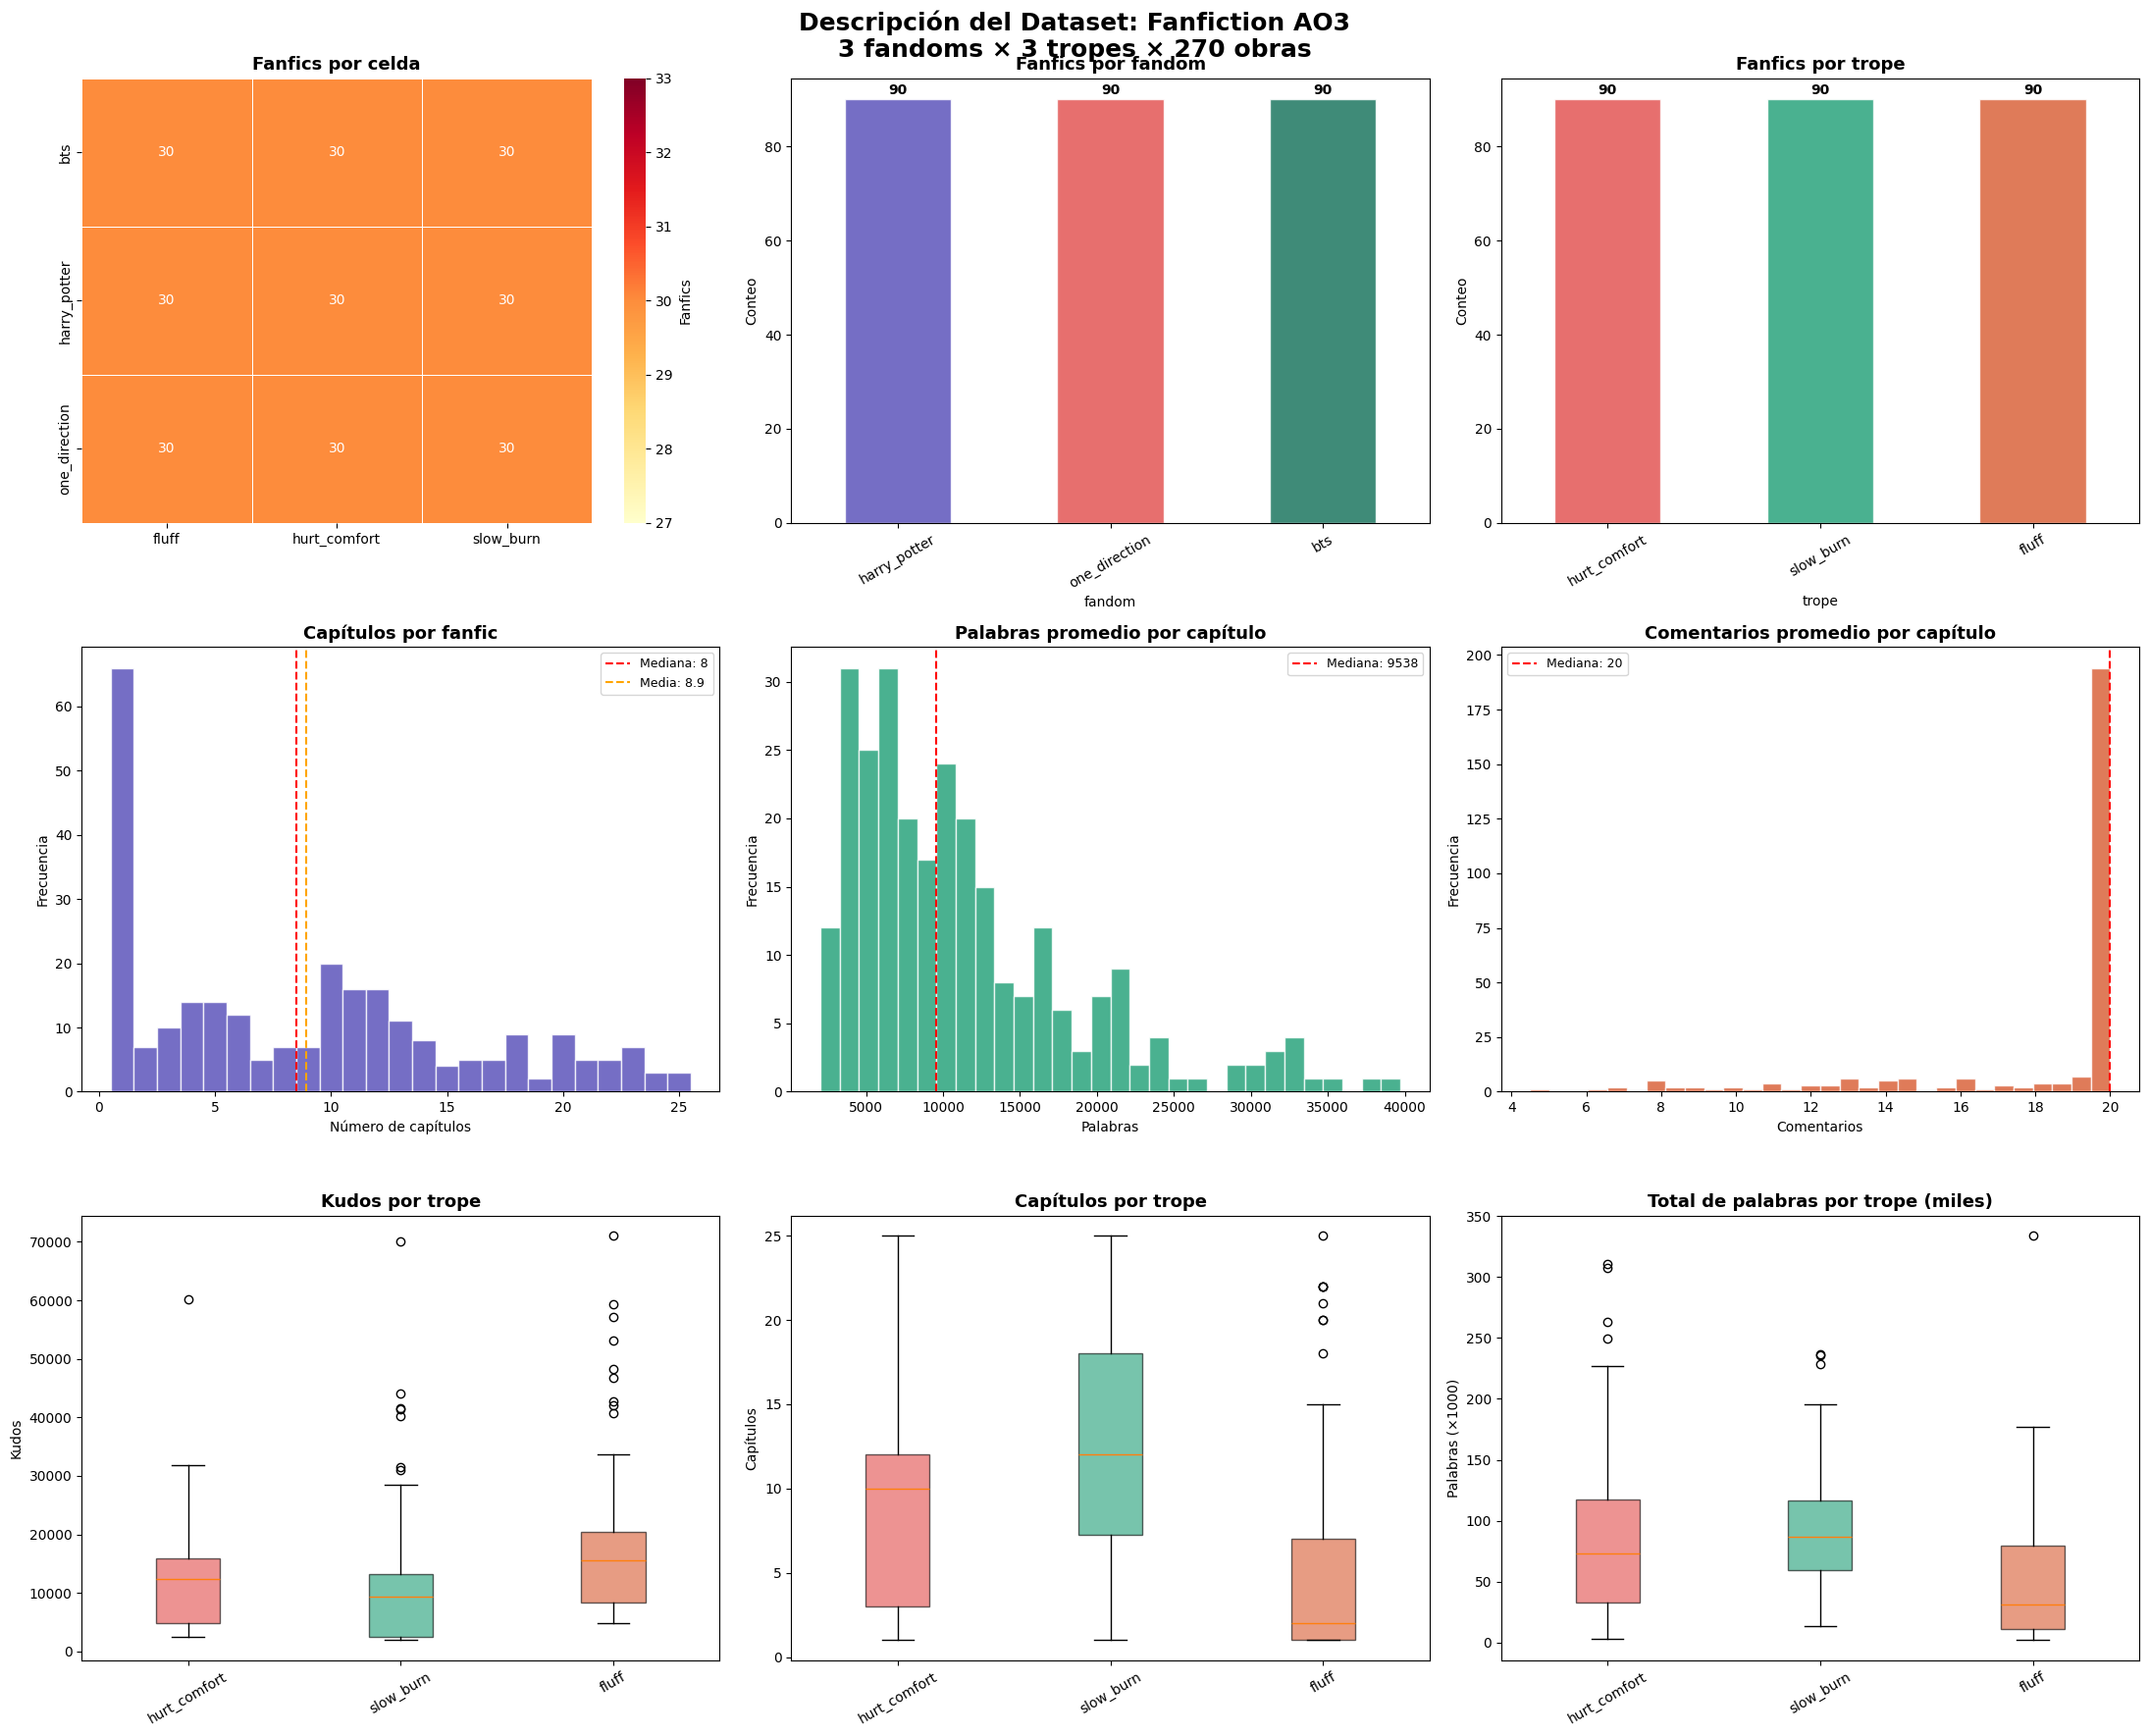


RESUMEN DEL DATASET
Total fanfics: 270
Fandoms: 3 (harry_potter, one_direction, bts)
Tropes: 3 (hurt_comfort, slow_burn, fluff)

Capítulos: 2413 totales | media=8.9 | mediana=8 | rango=[1-25]
Palabras: 20,797,388 totales | media/cap=11285
Comentarios: 42,396 totales | media/cap=18.2
Kudos: media=14105 | mediana=12188 | rango=[1928-71032]


In [3]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import seaborn as sns

# Asegurar que df ya está cargado del código anterior
print(f"Fanfics en dataset: {len(df)}")

fig = plt.figure(figsize=(22, 18))
fig.suptitle("Descripción del Dataset: Fanfiction AO3\n"
             "3 fandoms × 3 tropes × 270 obras",
             fontsize=18, fontweight="bold", y=0.98)


# 1. Distribución por fandom × trope (heatmap)

ax1 = fig.add_subplot(3, 3, 1)
pivot = df.groupby(["fandom", "trope"]).size().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", ax=ax1,
            cbar_kws={"label": "Fanfics"}, linewidths=0.5)
ax1.set_title("Fanfics por celda", fontsize=13, fontweight="bold")
ax1.set_xlabel("")
ax1.set_ylabel("")


# 2. Distribución por fandom (barras)

ax2 = fig.add_subplot(3, 3, 2)
fandom_counts = df["fandom"].value_counts()
colors_fandom = ["#534AB7", "#E24B4A", "#0F6E56"]
fandom_counts.plot(kind="bar", ax=ax2, color=colors_fandom, alpha=0.8, edgecolor="white")
ax2.set_title("Fanfics por fandom", fontsize=13, fontweight="bold")
ax2.set_ylabel("Conteo")
ax2.tick_params(axis="x", rotation=30)
for i, v in enumerate(fandom_counts):
    ax2.text(i, v + 1, str(v), ha="center", fontsize=10, fontweight="bold")

# 3. Distribución por trope (barras)

ax3 = fig.add_subplot(3, 3, 3)
trope_counts = df["trope"].value_counts()
colors_trope = ["#E24B4A", "#1D9E75", "#D85A30"]
trope_counts.plot(kind="bar", ax=ax3, color=colors_trope, alpha=0.8, edgecolor="white")
ax3.set_title("Fanfics por trope", fontsize=13, fontweight="bold")
ax3.set_ylabel("Conteo")
ax3.tick_params(axis="x", rotation=30)
for i, v in enumerate(trope_counts):
    ax3.text(i, v + 1, str(v), ha="center", fontsize=10, fontweight="bold")


# 4. Distribución de capítulos por fanfic

ax4 = fig.add_subplot(3, 3, 4)
ax4.hist(df["num_chapters"], bins=range(1, df["num_chapters"].max() + 2),
         color="#534AB7", alpha=0.8, edgecolor="white", align="left")
ax4.axvline(df["num_chapters"].median(), color="red", linestyle="--",
            label=f"Mediana: {df['num_chapters'].median():.0f}")
ax4.axvline(df["num_chapters"].mean(), color="orange", linestyle="--",
            label=f"Media: {df['num_chapters'].mean():.1f}")
ax4.set_title("Capítulos por fanfic", fontsize=13, fontweight="bold")
ax4.set_xlabel("Número de capítulos")
ax4.set_ylabel("Frecuencia")
ax4.legend(fontsize=9)

# 5. Palabras promedio por capítulo

ax5 = fig.add_subplot(3, 3, 5)
ax5.hist(df["avg_words_per_chapter"], bins=30, color="#1D9E75",
         alpha=0.8, edgecolor="white")
ax5.axvline(df["avg_words_per_chapter"].median(), color="red", linestyle="--",
            label=f"Mediana: {df['avg_words_per_chapter'].median():.0f}")
ax5.set_title("Palabras promedio por capítulo", fontsize=13, fontweight="bold")
ax5.set_xlabel("Palabras")
ax5.set_ylabel("Frecuencia")
ax5.legend(fontsize=9)


# 6. Comentarios promedio por capítulo

ax6 = fig.add_subplot(3, 3, 6)
ax6.hist(df["avg_comments_per_chapter"], bins=30, color="#D85A30",
         alpha=0.8, edgecolor="white")
ax6.axvline(df["avg_comments_per_chapter"].median(), color="red", linestyle="--",
            label=f"Mediana: {df['avg_comments_per_chapter'].median():.0f}")
ax6.set_title("Comentarios promedio por capítulo", fontsize=13, fontweight="bold")
ax6.set_xlabel("Comentarios")
ax6.set_ylabel("Frecuencia")
ax6.legend(fontsize=9)


# 7. Kudos por trope (boxplot)

ax7 = fig.add_subplot(3, 3, 7)
tropes_list = df["trope"].unique()
data_kudos = [df[df["trope"] == t]["kudos"].values for t in tropes_list]
bp = ax7.boxplot(data_kudos, labels=tropes_list, patch_artist=True)
for patch, color in zip(bp["boxes"], colors_trope[:len(tropes_list)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax7.set_title("Kudos por trope", fontsize=13, fontweight="bold")
ax7.set_ylabel("Kudos")
ax7.tick_params(axis="x", rotation=30)

# 8. Capítulos por trope (boxplot)

ax8 = fig.add_subplot(3, 3, 8)
data_caps = [df[df["trope"] == t]["num_chapters"].values for t in tropes_list]
bp2 = ax8.boxplot(data_caps, labels=tropes_list, patch_artist=True)
for patch, color in zip(bp2["boxes"], colors_trope[:len(tropes_list)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax8.set_title("Capítulos por trope", fontsize=13, fontweight="bold")
ax8.set_ylabel("Capítulos")
ax8.tick_params(axis="x", rotation=30)


# 9. Palabras por trope (boxplot)

ax9 = fig.add_subplot(3, 3, 9)
data_words = [df[df["trope"] == t]["total_words"].values / 1000 for t in tropes_list]
bp3 = ax9.boxplot(data_words, labels=tropes_list, patch_artist=True)
for patch, color in zip(bp3["boxes"], colors_trope[:len(tropes_list)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax9.set_title("Total de palabras por trope (miles)", fontsize=13, fontweight="bold")
ax9.set_ylabel("Palabras (×1000)")
ax9.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("results/dataset_descriptivo.png", dpi=150, bbox_inches="tight")
plt.show()


# Resumen estadístico

print("\n" + "="*60)
print("RESUMEN DEL DATASET")
print("="*60)
print(f"Total fanfics: {len(df)}")
print(f"Fandoms: {df['fandom'].nunique()} ({', '.join(df['fandom'].unique())})")
print(f"Tropes: {df['trope'].nunique()} ({', '.join(df['trope'].unique())})")
print(f"\nCapítulos: {df['num_chapters'].sum()} totales | "
      f"media={df['num_chapters'].mean():.1f} | "
      f"mediana={df['num_chapters'].median():.0f} | "
      f"rango=[{df['num_chapters'].min()}-{df['num_chapters'].max()}]")
print(f"Palabras: {df['total_words'].sum():,} totales | "
      f"media/cap={df['avg_words_per_chapter'].mean():.0f}")
print(f"Comentarios: {df['total_comments'].sum():,} totales | "
      f"media/cap={df['avg_comments_per_chapter'].mean():.1f}")
print(f"Kudos: media={df['kudos'].mean():.0f} | "
      f"mediana={df['kudos'].median():.0f} | "
      f"rango=[{df['kudos'].min()}-{df['kudos'].max()}]")